In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import openpyxl
from openpyxl.styles import Font, PatternFill, Alignment, Border, Side
from openpyxl.utils import get_column_letter

sns.set_theme(style="whitegrid")

In [2]:
df=pd.read_csv("blc-8.csv")
df.head()

,S.No,Country,City,Company,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,CONTACT,Google Map,Category,Reviews,Comments
0,1,India,Maharashtra,Sarthak Medical And Ganral Stors,NaN,NaN,NaN,NaN,+91 99226 29928,Sarthak Medical And Ganral Stors,Pharmacy,0.0,0
1,2,India,Maharashtra,MANDALE MEDICAL,NaN,NaN,NaN,NaN,+91 77200 02552,MANDALE MEDICAL,Pharmacy,5.0,2
2,3,India,Maharashtra,Rayba Pharmacy,NaN,NaN,NaN,NaN,+91 82753 55016,Rayba Pharmacy,Pharmacy,5.0,1
3,4,India,Maharashtra,Annapurna Medical,NaN,NaN,NaN,NaN,+91 89997 66245,Annapurna Medical,Pharmacy,0.0,0
4,5,India,Maharashtra,KES College Of Pharmacy,NaN,NaN,NaN,NaN,+91 2587 223 103,KES College Of Pharmacy,Pharmacy,2.5,4


In [3]:
df['Category'].unique()

array(['Pharmacy', 'Restaurant', 'Caoching Center', 'Tutoring service',
       'Education Center', 'Training Center', 'Computer Training School',
       'Education Intstitution', 'Software Training Institute',
       'Institute of technology', 'Educational Institute',
       'Medical clinic', 'Medical Center', 'Surgeon', 'Hospital',
       'Medical Centre', 'Obstetrician-gynecologist', 'Surgical center',
       'Skin care clinic', 'Ayurvedic clinic', 'Coaching Center',
       'General practitioner', 'Doctor', 'Free Clinic',
       'Community health center', 'Maternity Centre', 'Nursing Home',
       'Banking entrance coaching center', 'Computer Service',
       'Educational institution', 'Health consultant', 'Dermatologist',
       'Acupuncture clinic', 'General Hospital', 'Pediatrician',
       'Computer training school', 'Nursing school', 'Health Spa',
       'Computer Center', 'Computer networking service',
       'Training center', 'Public health department',
       'Social service

In [4]:
df["Category"] = df["Category"].str.strip().str.title().fillna("Unknown")

def map_to_standard_category(cat):
    cat_lower = str(cat).lower().strip()

    if 'coaching' in cat_lower or 'caoching' in cat_lower or 'tutoring' in cat_lower or 'tuition' in cat_lower:
        return 'Coaching Center'
    if 'training' in cat_lower or 'education' in cat_lower or 'educational' in cat_lower or 'institute' in cat_lower or 'university' in cat_lower or 'school' in cat_lower or 'computer center' in cat_lower or 'vocational' in cat_lower or 'computer service' in cat_lower or 'computer networking' in cat_lower:
        return 'Training Center'
    if 'dermatologist' in cat_lower or 'skin' in cat_lower:
        return 'Dermatologist'
    if 'physio' in cat_lower:
        return 'Physiotherapy Clinic'
    if 'homeopath' in cat_lower or 'homeopathic' in cat_lower or 'holistic' in cat_lower or 'ayurvedic' in cat_lower or 'acupuncture' in cat_lower:
        return 'Homeopathy Clinic'
    if 'pharmacy' in cat_lower:
        return 'Pharmacy'
    if 'restaurant' in cat_lower or 'food' in cat_lower:
        return 'Restaurant'
    if 'gym' in cat_lower or 'spa' in cat_lower or 'salon' in cat_lower:
        return 'Salon'
    if 'nursing' in cat_lower or 'maternity' in cat_lower:
        return 'Nursing & Maternity'
    if 'pediatrician' in cat_lower or 'child' in cat_lower:
        return 'Pediatric Clinic'
    if any(keyword in cat_lower for keyword in ['medical', 'clinic', 'hospital', 'doctor', 'health', 'surgeon', 'practitioner', 'care', 'surgical', 'obstetrician', 'community', 'government', 'public', 'social']):
        return 'Medical Clinic'

    return 'Training Center'

df['Standard_Category'] = df['Category'].apply(map_to_standard_category)
print(f"Total records: {len(df)}")
print(df['Standard_Category'].value_counts())

Total records: 297
Standard_Category
Medical Clinic          103
Training Center          74
Coaching Center          41
Homeopathy Clinic        25
Pharmacy                 20
Physiotherapy Clinic     20
Restaurant                5
Dermatologist             4
Nursing & Maternity       2
Salon                     2
Pediatric Clinic          1
Name: count, dtype: int64


In [5]:
india_ranks = {
    'Training Center': 1,
    'Coaching Center': 2,
    'Physiotherapy Clinic': 3,
    'Medical Clinic': 4,
    'Homeopathy Clinic': 5,
    'Dermatologist': 6,
    'Pharmacy': 7,
    'Nursing & Maternity': 8,
    'Pediatric Clinic': 9,
    'Restaurant': 10,
    'Salon': 11,
    'Grocery Store': 12,
    'Dairy Shop': 13
}

foreign_ranks = {
    'Medical Clinic': 1,
    'Physiotherapy Clinic': 2,
    'Dermatologist': 3,
    'Homeopathy Clinic': 4,
    'Training Center': 5,
    'Coaching Center': 6,
    'Pharmacy': 7,
    'Nursing & Maternity': 8,
    'Pediatric Clinic': 9,
    'Restaurant': 10,
    'Salon': 11,
    'Grocery Store': 12,
    'Dairy Shop': 13
}

def assign_lead_score_and_rank(row):
    country = str(row['Country']).strip().lower()
    cat = row['Standard_Category']

    if 'india' in country:
        rank = india_ranks.get(cat, 13)
        if rank <= 4: return pd.Series([0.85, rank])
        elif rank <= 9: return pd.Series([0.55, rank])
        else: return pd.Series([0.15, rank])
    else:
        rank = foreign_ranks.get(cat, 13)
        if rank <= 4: return pd.Series([0.85, rank])
        elif rank <= 9: return pd.Series([0.55, rank])
        else: return pd.Series([0.15, rank])

df[['Conversion_Probability', 'Rank']] = df.apply(assign_lead_score_and_rank, axis=1)
print(df[['Country', 'Standard_Category', 'Rank', 'Conversion_Probability']].head(20))

   Country Standard_Category  Rank  Conversion_Probability
0    India          Pharmacy   7.0                    0.55
1    India          Pharmacy   7.0                    0.55
2    India          Pharmacy   7.0                    0.55
3    India          Pharmacy   7.0                    0.55
4    India          Pharmacy   7.0                    0.55
5    India          Pharmacy   7.0                    0.55
6    India          Pharmacy   7.0                    0.55
7    India          Pharmacy   7.0                    0.55
8    India          Pharmacy   7.0                    0.55
9    India          Pharmacy   7.0                    0.55
10   India          Pharmacy   7.0                    0.55
11   India          Pharmacy   7.0                    0.55
12   India          Pharmacy   7.0                    0.55
13   India          Pharmacy   7.0                    0.55
14   India          Pharmacy   7.0                    0.55
15   India          Pharmacy   7.0                    0.

In [6]:
df['Reviews'] = pd.to_numeric(df['Reviews'], errors='coerce').fillna(0.0)
df['Comments'] = pd.to_numeric(df['Comments'], errors='coerce').fillna(0.0)

df['Reviews_Normalized'] = df['Reviews']/5

max_comments = df['Comments'].max()
df['Comments_Normalized'] = np.log1p(df['Comments']) / np.log1p(max_comments)

df['Lead_Score'] = (df['Reviews_Normalized'] + df['Comments_Normalized'])/2

print(df[['Company', 'Reviews', 'Comments', 'Reviews_Normalized', 'Comments_Normalized', 'Lead_Score']].head(10))

                            Company  Reviews  Comments  Reviews_Normalized  \
0  Sarthak Medical And Ganral Stors      0.0         0                0.00   
1                   MANDALE MEDICAL      5.0         2                1.00   
2                    Rayba Pharmacy      5.0         1                1.00   
3                 Annapurna Medical      0.0         0                0.00   
4           KES College Of Pharmacy      2.5         4                0.50   
5   Kalika Medical & General Stores      5.0         2                1.00   
6                          FARMTRAC      0.0         0                0.00   
7            HCBL Vaishnavi Medical      0.0         0                0.00   
8     Aai Medical and general store      4.8         4                0.96   
9              Mayur medical stores      3.8         6                0.76   

   Comments_Normalized  Lead_Score  
0             0.000000    0.000000  
1             0.142789    0.571395  
2             0.090090    0.54

In [7]:
df['Final_Score'] = (df['Conversion_Probability']*0.6) + (df['Lead_Score']*0.4)

print(df[['Company', 'Standard_Category', 'Conversion_Probability', 'Lead_Score', 'Final_Score']].head(30))

                                           Company Standard_Category  \
0                 Sarthak Medical And Ganral Stors          Pharmacy   
1                                  MANDALE MEDICAL          Pharmacy   
2                                   Rayba Pharmacy          Pharmacy   
3                                Annapurna Medical          Pharmacy   
4                          KES College Of Pharmacy          Pharmacy   
5                  Kalika Medical & General Stores          Pharmacy   
6                                         FARMTRAC          Pharmacy   
7                           HCBL Vaishnavi Medical          Pharmacy   
8                    Aai Medical and general store          Pharmacy   
9                             Mayur medical stores          Pharmacy   
10               New Life Care Pharmacy And Clinic          Pharmacy   
11  Hirakani Medical and General Stores jalgaon ni          Pharmacy   
12         Shree Swami Samarth Chemist And Dragist          Phar

In [8]:
df["Company_Name_Length"] = df["Company"].str.len()
df["Company_Word_Count"] = df["Company"].str.split().str.len()

category_counts_dict = df["Standard_Category"].value_counts().to_dict()
df["Category_Frequency"] = df["Standard_Category"].map(category_counts_dict)

city_counts_dict = df["City"].value_counts().to_dict()
df["City_Frequency"] = df["City"].map(city_counts_dict)

le_city = LabelEncoder()
df["City_Encoded"] = le_city.fit_transform(df["City"])

le_category = LabelEncoder()
df["Category_Encoded"] = le_category.fit_transform(df["Standard_Category"])

print("Features created!")
print(df[["Company_Name_Length", "Company_Word_Count", "Category_Frequency", "City_Frequency"]].head())

Features created!
   Company_Name_Length  Company_Word_Count  Category_Frequency  City_Frequency
0                   32                   5                  20              20
1                   15                   2                  20              20
2                   14                   2                  20              20
3                   17                   2                  20              20
4                   23                   4                  20              20


In [9]:
print("Generating Exploratory Data Analysis & Plotting Graphs...")

# --- GRAPH 1: Distribution of Businesses by City ---
city_data = df["City"].value_counts().reset_index()
city_data.columns = ["City", "Count"]
city_data = city_data.sort_values(by="Count", ascending=False).head(15)

fig1, ax1 = plt.subplots(figsize=(10, 6))
sns.barplot(data=city_data, x="Count", y="City", palette="Blues_r", ax=ax1)
ax1.set_title("Distribution of Businesses by City (Top 15)", fontsize=14, fontweight="bold")
ax1.set_xlabel("Number of Businesses", fontsize=12)
ax1.set_ylabel("City", fontsize=12)
plt.tight_layout()
plt.savefig("distribution_of_businesses_by_city.png")
plt.close()

# --- GRAPH 2: Business Categories by Total Count ---
category_counts = df["Standard_Category"].value_counts().reset_index()
category_counts.columns = ["Standard_Category", "Count"]
category_counts = category_counts.sort_values(by="Count", ascending=False)

fig2, ax2 = plt.subplots(figsize=(12, 6))
sns.barplot(data=category_counts, x="Count", y="Standard_Category", palette="mako", ax=ax2)
ax2.set_title("Business Categories by Total Count", fontsize=14, fontweight="bold")
ax2.set_xlabel("Number of Businesses", fontsize=12)
ax2.set_ylabel("Business Category", fontsize=12)
plt.tight_layout()
plt.savefig("top_business_categories_by_count.png")
plt.close()

print("Initial Graphs Generated successfully.")

Generating Exploratory Data Analysis & Plotting Graphs...


/tmp/ipykernel_48229/963016871.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=city_data, x="Count", y="City", palette="Blues_r", ax=ax1)


Initial Graphs Generated successfully.


/tmp/ipykernel_48229/963016871.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=category_counts, x="Count", y="Standard_Category", palette="mako", ax=ax2)


In [10]:
feature_names = ["Company_Name_Length", "Company_Word_Count",
                 "Category_Frequency", "City_Frequency",
                 "City_Encoded", "Category_Encoded",
                 "Reviews_Normalized", "Comments_Normalized"]

X = df[feature_names]
y = df["Final_Score"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

xgb_model = XGBRegressor(
    n_estimators=100,
    max_depth=4,
    random_state=42,
    learning_rate=0.1
)
xgb_model.fit(X_train, y_train)

print(f"Final Training R² Score: {xgb_model.score(X_train, y_train):.4f}")
print(f"Final Testing R² Score: {xgb_model.score(X_test, y_test):.4f}")

df["Predicted_Probability"] = xgb_model.predict(X)

print(df[['Company', 'Standard_Category', 'Final_Score', 'Predicted_Probability']].head(10))

Final Training R² Score: 0.9991
Final Testing R² Score: 0.9820
                            Company Standard_Category  Final_Score  \
0  Sarthak Medical And Ganral Stors          Pharmacy     0.330000   
1                   MANDALE MEDICAL          Pharmacy     0.558558   
2                    Rayba Pharmacy          Pharmacy     0.548018   
3                 Annapurna Medical          Pharmacy     0.330000   
4           KES College Of Pharmacy          Pharmacy     0.471837   
5   Kalika Medical & General Stores          Pharmacy     0.558558   
6                          FARMTRAC          Pharmacy     0.330000   
7            HCBL Vaishnavi Medical          Pharmacy     0.330000   
8     Aai Medical and general store          Pharmacy     0.563837   
9              Mayur medical stores          Pharmacy     0.532583   

   Predicted_Probability  
0               0.327864  
1               0.549127  
2               0.548601  
3               0.330116  
4               0.461069  
5   

In [11]:
# Graph 3 - Categories by Predicted Probability
category_rankings = df.groupby("Standard_Category")["Predicted_Probability"].mean().reset_index()
category_rankings = category_rankings.sort_values(by="Predicted_Probability", ascending=False)

fig3, ax3 = plt.subplots(figsize=(12, 6))
sns.barplot(data=category_rankings, x="Predicted_Probability", y="Standard_Category", palette="viridis", ax=ax3)
ax3.set_title("Business Categories by Predicted Conversion Probability")
ax3.set_xlabel("Average Predicted Probability")
ax3.set_ylabel("Business Category")
plt.tight_layout()
plt.savefig("top_business_categories_by_probability.png")
plt.close()

/tmp/ipykernel_48229/3667599373.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=category_rankings, x="Predicted_Probability", y="Standard_Category", palette="viridis", ax=ax3)


In [13]:
country_counts = df["Country"].value_counts().reset_index()
country_counts.columns = ["Country", "Count"]

fig4, ax4 = plt.subplots(figsize=(8, 5))
sns.barplot(data=country_counts, x="Count",y="Country",palette="coolwarm",ax=ax4)
ax4.set_title("Lead Volume by Country")
ax4.set_xlabel("Number of Businesses")
ax4.set_ylabel("Country")
plt.tight_layout()
plt.savefig("lead_volume_by_country.png")
plt.close()
print("All graphs saved!")

All graphs saved!


/tmp/ipykernel_48229/4188027276.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=country_counts, x="Count",y="Country",palette="coolwarm",ax=ax4)


In [16]:
columns_to_export = ["S.No", "Country", "City", "Company", "CONTACT", "Google Map", "Category",
                      "Standard_Category", "Rank", "Lead_Score", "Final_Score", "Predicted_Probability"]

indian_df = df[df["Country"].str.lower().str.contains("india")].sort_values(by="Predicted_Probability", ascending=False)[columns_to_export]
foreign_df = df[~df["Country"].str.lower().str.contains("india")].sort_values(by="Predicted_Probability", ascending=False)[columns_to_export]

wb = openpyxl.Workbook()
wb.remove(wb.active)
sheets_config = {
    f"Indian Businesses ({len(indian_df)})": (indian_df, "365F91"),   # Corporate Blue
    f"Foreign Businesses ({len(foreign_df)})": (foreign_df, "5C5C5C") # Slate Gray
}

for sheet_name, (sub_df, header_color) in sheets_config.items():
    ws = wb.create_sheet(title=sheet_name)
    ws.views.sheetView[0].showGridLines = True

    headers = list(sub_df.columns)
    ws.append(headers)

    header_font = Font(name="Calibri", size=11, bold=True, color="FFFFFF")
    header_fill = PatternFill(start_color=header_color, end_color=header_color, fill_type="solid")
    center_align = Alignment(horizontal="center", vertical="center", wrap_text=True)
    left_align = Alignment(horizontal="left", vertical="center")
    thin_border = Border(
        left=Side(style="thin", color="DDDDDD"), right=Side(style="thin", color="DDDDDD"),
        top=Side(style="thin", color="DDDDDD"), bottom=Side(style="thin", color="DDDDDD")
    )

    for col_num, header in enumerate(headers, 1):
        cell = ws.cell(row=1, column=col_num)
        cell.font = header_font
        cell.fill = header_fill
        cell.alignment = center_align

    for r_idx, row_data in enumerate(sub_df.values, 2):
        for c_idx, value in enumerate(row_data, 1):
            cell = ws.cell(row=r_idx, column=c_idx, value=value)
            cell.border = thin_border
            cell.font = Font(name="Calibri", size=11)

            current_header = headers[c_idx - 1]

            if current_header in ["S.No", "CONTACT", "Rank"]:
                cell.alignment = center_align
                if current_header == "CONTACT":
                    cell.number_format = "@"
            elif current_header == "Predicted_Probability":
                cell.alignment = center_align
                cell.number_format = "0.0%"
            else:
                cell.alignment = left_align


    for col in ws.columns:
        max_len = max(len(str(cell.value or "")) for cell in col)
        col_letter = get_column_letter(col[0].column)
        ws.column_dimensions[col_letter].width = max(max_len + 3, 12)

# Save Outputs Safely
wb.save("leads_prioritized_by_country.xlsx")
df.to_csv("business_leads_prioritized.csv", index=False)

print("\n--- PROCESS COMPLETE ---")
print("Successfully generated 'business_leads_prioritized.csv'")
print("Successfully generated 'leads_prioritized_by_country.xlsx' with Indian and Foreign sheets sorted by Predicted_Probability!")


--- PROCESS COMPLETE ---
Successfully generated 'business_leads_prioritized.csv'
Successfully generated 'leads_prioritized_by_country.xlsx' with Indian and Foreign sheets sorted by Predicted_Probability!


In [17]:
from sklearn.linear_model import LogisticRegression
median_comments = df['Comments'].median()
df['Target_Label'] = ((df['Reviews'] >= 4.5) & (df['Comments'] >= median_comments)).astype(int)

X = df[['Reviews', 'Comments']]
y = df['Target_Label']

from sklearn.linear_model import LogisticRegression
model = LogisticRegression(random_state=42)
model.fit(X, y)

df['Review_Based_Probability'] = model.predict_proba(X)[:, 1]
print(df['Target_Label'].value_counts())

Target_Label
0    164
1    133
Name: count, dtype: int64


In [20]:
df_sorted = df.sort_values(
    by=['Review_Based_Probability', 'Reviews', 'Comments'],
    ascending=[False, False, False]
).reset_index(drop=True)

total = len(df_sorted)
high_cutoff = int(total*0.28)   # roughly 28% of total
medium_cutoff = int(total*0.65)  # roughly 28% + 37% of total

high_priority = df_sorted.iloc[0:high_cutoff].copy()
medium_priority = df_sorted.iloc[high_cutoff:medium_cutoff].copy()
low_priority = df_sorted.iloc[medium_cutoff:total].copy()

print(f"High: {len(high_priority)}, Medium: {len(medium_priority)}, Low: {len(low_priority)}")

High: 83, Medium: 110, Low: 104


In [28]:
columns_to_export = [
    "S.No",
    "Country",
    "City",
    "Company",
    "CONTACT",
    "Google Map",
    "Category",
    "Review_Based_Probability"
]

high_priority_final = high_priority[columns_to_export]
medium_priority_final = medium_priority[columns_to_export]
low_priority_final = low_priority[columns_to_export]

output_filename = 'Reviews_Comments_based_ Leads.xlsx'

with pd.ExcelWriter(output_filename) as writer:
    high_priority_final.to_excel(writer, sheet_name=f'High Priority ({len(high_priority)})', index=False)
    medium_priority_final.to_excel(writer, sheet_name=f'Medium Priority', index=False)
    low_priority_final.to_excel(writer, sheet_name=f'Low priority', index=False)

print(f"Excel File successfully created: '{output_filename}'")


Excel File successfully created: 'Reviews_Comments_based_ Leads.xlsx'


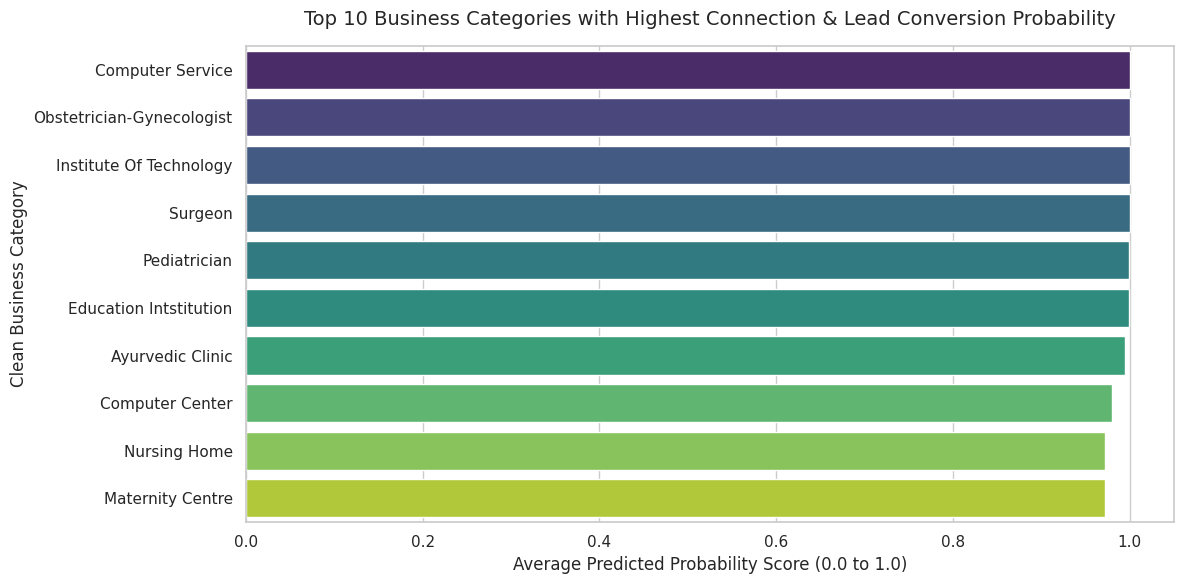

Visualization generated and saved successfully as 'top_converting_categories_updated.png'.


In [31]:
visualization_df = pd.concat([high_priority_final, medium_priority_final])
category_performance = visualization_df.groupby('Category')['Review_Based_Probability'].mean().reset_index()
category_performance_sorted = category_performance.sort_values(by='Review_Based_Probability', ascending=False).head(10)

fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(
    data=category_performance_sorted,
    x='Review_Based_Probability',
    y='Category',
    ax=ax,
    palette='viridis',
    hue='Category'
)

ax.set_title('Top 10 Business Categories with Highest Connection & Lead Conversion Probability', fontsize=14, pad=15)
ax.set_xlabel('Average Predicted Probability Score (0.0 to 1.0)', fontsize=12)
ax.set_ylabel('Clean Business Category', fontsize=12)

plt.tight_layout()
plt.savefig('top_converting_categories_updated.png', dpi=300)
plt.show()
print("Visualization generated and saved successfully as 'top_converting_categories_updated.png'.")